# Übung 2 - Aufgabe 1 - Klassifikation von Katzen und Hunden

In dieser Aufgabe soll der im Buch vorgestellte Datensatz verwendet werden, um Katzen und Hunde zu klassifizieren. Im Gegensatz zur vorherigen Aufgabe soll in dieser allerdings mittels fortgeschritteneren Netzen klassifiziert werden. Verwenden Sie dazu CNNs folgender Typen:

- Ein eigenes CNN angelehnt an das aus dem Buch
- Ein VGG Ihrer Wahl
- Ein ResNet Ihrer Wahl

Verwenden Sie zusätzlich ein Netz auf Basis von Vision Transformern. Vergleichen Sie die Ergebnisse. Gehen Sie auf diese Weise vor ist es sinnvoll sich für das Training eine wiederverwendbare Funktion zu schreiben.

Diese Aufgabe ist folgendermaßen aufgebaut:

1. Vornehmen nötiger Imports
2. Laden der Daten
3. Definition des eigenen CNN
4. Anlegen der neuronalen Netze
5. Training und Tests der neuronalen Netze

## 1. Nötige Imports vornehmen

Die folgende Code-Zelle importiert die notwendigen Bibliotheken, die im Folgenden benötigt werden.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch import optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms, datasets, models
from tqdm.notebook import tqdm

## 2. Trainingsdaten laden

Zunächst werden die Trainingsdaten aus dem Verzeichnis geladen. Hierbei können Sie wie im Buch beschrieben vorgehen.

In [2]:
# ImageNet-Werte für Normalize
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15), # Random rotation in degrees
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

valid_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

path_to_datasests = 'DL/AKI_Aufgaben_Deep_Learning/Veranstaltung_2/Aufgabe_1/Data'

# Hier die Daten mittels ImageFolder in Trainset und Validset einlesen
train_set = datasets.ImageFolder(
    root=os.path.join(path_to_datasests, 'train'),
    transform=train_transform)
valid_set = datasets.ImageFolder(
    root=os.path.join(path_to_datasests, 'valid'),
    transform=valid_transform)

Im Folgenden kann eines der Bilder angezeigt werden.

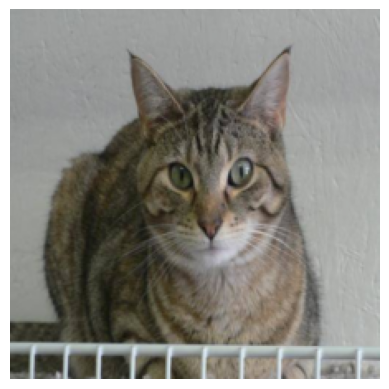

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def imshow(inp):
    # Tensor zu NumPy, Dimensionen tauschen von (C, H, W) zu (H, W, C)
    inp = inp.numpy().transpose((1, 2, 0))

    # Normalisierung rückgängig machen, damit die Farben wieder stimmen
    inp = std * inp + mean

    # Erst jetzt sicher auf [0, 1] clippen für matplotlib
    inp = np.clip(inp, 0, 1)

    plt.imshow(inp)
    plt.axis('off')
    plt.show()

# Testen:
imshow(train_set[30][0])

Die Daten werden nun einem Data Loader übergeben, welcher eine Zufallsverteilung und eine Organisation in "batches" vornimmt.


In [4]:
BATCH_SIZE = 64

train_loader = DataLoader(
    train_set,
    shuffle=True,
    batch_size=BATCH_SIZE,
    num_workers=0,
    pin_memory=True
)

valid_loader = DataLoader(
    valid_set,
    batch_size=BATCH_SIZE,
    num_workers=0,
    pin_memory=True
)

## 3. Definition des eigenen CNN

Nutzen Sie die vorgegebene Klasse CNN, um ein eigenes CNN zu implementieren. Aufgrund der Größe der Eingabebilder, sollte dieses mindestens 4-5 Conv2D-Schichten enthalten.

In [36]:
num_classes = 2

class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        # Initialisieren Sie hier Ihre CNN und FC Layer.
        # === CNN Blöcke ===
        # CNN Block 1: 3 -> 10 channels
        self.conv11 = nn.Conv2d(3, 10, kernel_size=3, padding=1)
        self.bn11 = nn.BatchNorm2d(10)
        # self.conv12 = nn.Conv2d(10, 10, kernel_size=3, padding=1)
        # self.bn12 = nn.BatchNorm2d(10)


        # CNN Block 2: 10 -> 20 channels
        self.conv21 = nn.Conv2d(10, 20, kernel_size=3, padding=1)
        self.bn21 = nn.BatchNorm2d(20)
        # self.conv22 = nn.Conv2d(20, 20, kernel_size=3, padding=1)
        # self.bn22 = nn.BatchNorm2d(20)

        # # CNN Block 3: 20 -> 40 channels
        self.conv31 = nn.Conv2d(20, 40, kernel_size=3, padding=1)
        self.bn31 = nn.BatchNorm2d(40)
        # self.conv32 = nn.Conv2d(40, 40, kernel_size=3, padding=1)
        # self.bn32 = nn.BatchNorm2d(40)
        #
        # # CNN Block 4: 40 -> 80 channels
        self.conv41 = nn.Conv2d(40, 80, kernel_size=3, padding=1)
        self.bn41 = nn.BatchNorm2d(80)
        # self.conv42 = nn.Conv2d(80, 80, kernel_size=3, padding=1)
        # self.bn42 = nn.BatchNorm2d(80)

        # === Classifier Blöcke ===
        # FC Block 1: 80*14*14 = 15.680 Features -> 256 Outputs
        self.fc1 = nn.Linear(80*14*14, 256)
        self.dropout1 = nn.Dropout(p=0.3)

        # FC Block 2: 256 Features -> 2 Features
        self.fc2 = nn.Linear(256, 2)

    def forward(self, x):
        # Implementieren Sie hier die Verbindung zwischen den Layern.
        # === Feature Extractor ===
        # Block 1
        x = F.relu(self.bn11(self.conv11(x)))
        # x = F.relu(self.bn12(self.conv12(x)))
        x = F.max_pool2d(x, kernel_size=2, stride=2)

        # Block 2
        x = F.relu(self.bn21(self.conv21(x)))
        # x = F.relu(self.bn22(self.conv22(x)))
        x = F.max_pool2d(x, kernel_size=2, stride=2)

        # # Block 3
        x = F.relu(self.bn31(self.conv31(x)))
        # x = F.relu(self.bn32(self.conv32(x)))
        x = F.max_pool2d(x, kernel_size=2, stride=2)
        #
        # # Block 4
        x = F.relu(self.bn41(self.conv41(x)))
        # x = F.relu(self.bn42(self.conv42(x)))
        x = F.max_pool2d(x, kernel_size=2, stride=2)

        # === Flattening ===
        x = torch.flatten(x, start_dim=1) # ist robuster als x = x.view(x.size(0), -1)

        # === Classifier ===
        # Block 1
        x = F.relu(self.fc1(x))
        x = self.dropout1(x)
        x = self.fc2(x) # Gibt reine Logits zurück

        return x

## 4. Anlegen der neuronalen Netze

Legen Sie in der nächsten Zelle die vier Netze der vorgegebenen Typen an. Denken Sie daran die Ausgabe auf die Anzahl der vorliegenden Klassen anzupassen. Beim VGG lässt sich dies im letzten Layer der Sequenz "classifier" und beim Vision Transformer im letzten Layer der Sequenz "heads" setzen. Das ResNet können Sie wie im Kapitel 3 beschrieben anpassen.

In [24]:
vgg = models.vgg16(weights=models.VGG16_Weights.DEFAULT)
vgg

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [25]:
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
resnet

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [26]:
vit = models.vit_b_16(weights=models.ViT_B_16_Weights.DEFAULT)
vit

VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_a

In [53]:
def prepare_vgg(model, n_classes, dropout=0.2, freeze_all=False):
    if freeze_all: # Convolution-Block (Feature-Extractor) & Classifier-Block einfrieren
        for param in model.parameters():
            param.requires_grad = False
    else: # Convolution-Block (Feature-Extractor) einfrieren → Classifier-Block wird nicht eingefroren!
        for param in model.features.parameters():
            param.requires_grad = False

    # Im Classifier-Block die letzte Schicht austauschen
    in_features = model.classifier[-1].in_features
    model.classifier[-1] = nn.Linear(in_features=in_features, out_features=n_classes)

    # Dropout-Rate im Classifier-Block anpassen
    for module in model.classifier.modules():
        if isinstance(module, nn.Dropout):
            module.p = dropout
    return model


def prepare_resnet(model, n_classes):
    # Alle Blöcke und Schichten einfrieren
    for param in model.parameters():
        param.requires_grad = False

    # Im Classifier-Block sitzt nur eine lineare Schicht, diese austauschen
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features=in_features, out_features=n_classes)
    return model


def prepare_vit(model, n_classes):
    # Alle Blöcke und Schichten einfrieren
    # Da ViT kompakter aufgebaut ist, friert man oft einfach alles ein und ersetzt nur den Kopf:
    for param in model.parameters():
        param.requires_grad = False

    # Der Kopf von torchvision ViT ist ein Sequential, dessen einziges Element eine lineare Schicht ist
    in_features = model.heads[-1].in_features
    # model.heads = nn.Linear(in_features=in_features, out_features=n_classes)
    model.heads[-1] = nn.Linear(in_features=in_features, out_features=n_classes)
    return model


def instantiate_model(model_choice):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    num_classes = 2

    if model_choice == 'cnn':
        model = CNN()
    elif model_choice == 'vgg':
        model = models.vgg16(weights=models.VGG16_Weights.DEFAULT)
        model = prepare_vgg(model, num_classes)
    elif model_choice == 'resnet':
        model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        model = prepare_resnet(model, num_classes)
    elif model_choice == 'vit':
        model = models.vit_b_16(weights=models.ViT_B_16_Weights.DEFAULT)
        model = prepare_vit(model, num_classes)
    else:
        raise ValueError("Invalid model choice. Choose from 'cnn', 'vgg', 'resnet', or 'vit'.")

    model = model.to(device)

    return model

## 5. Training des Modells

Schreiben Sie in die Funktion "train_model" die Trainingslogik der neuronalen Netze. Hier können Sie ähnlich wie bei der MNIST-Aufgabe vorgehen. Die Funktion "plot_results" kann Genauigkeit und Verlust als Plot darstellen.

In [28]:
def plot_results(epochs, training_acc, testing_acc, training_loss, testing_loss):
    plt.plot(range(epochs), training_acc, label="train_acc")
    plt.plot(range(epochs), testing_acc, label="valid_acc")
    plt.legend()
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.grid(True)
    plt.show()

    plt.plot(range(epochs), training_loss, label="train_loss")
    plt.plot(range(epochs), testing_loss, label="valid_loss")
    plt.legend()
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.grid(True)
    plt.show()

def train_model(model, epochs=10, optimizer='SGD', learning_rate=0.001, momentum: float=0.9):
    # Verlustfunktion und Optimizer initialisieren
    criterion = nn.CrossEntropyLoss()
    if optimizer == 'SGD':
        optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=momentum)
    elif optimizer == 'Adam':
        optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    training_loss = []
    testing_loss = []
    training_acc = []
    testing_acc = []

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)

    # Gesamtzahl der Samples einmalig ermitteln
    total_train_samples = len(train_loader.dataset)
    total_valid_samples = len(valid_loader.dataset)

    with tqdm(range(epochs)) as iterator:
        for epoch in iterator:
            # --- TRAINING ---
            train_loss = 0
            train_acc = 0
            model.train()
            for inputs, targets in train_loader:
                inputs, targets = inputs.to(device), targets.to(device)

                optimizer.zero_grad()
                loss = criterion(model(inputs), targets)
                loss.backward()
                optimizer.step()

                # Metriken akkumulieren
                train_loss += loss.item() * inputs.size(0)
                preds = model(inputs).argmax(dim=1)
                train_acc += preds.eq(targets).sum().item()

            epoch_train_loss = train_loss / total_train_samples
            epoch_train_acc = train_acc / total_train_samples

            training_loss.append(epoch_train_loss)
            training_acc.append(epoch_train_acc)

            # --- VALIDIERUNG ---
            test_loss = 0
            test_acc = 0
            model.eval() # Droput- und BatchNorm-Layer werden in Evaluation-Mode gesetzt
            with torch.no_grad(): # Verhindert, dass für Validierung Berechnungsgraphen für Gradienten aufgebaut wird
                for inputs, targets in valid_loader:
                    inputs, targets = inputs.to(device), targets.to(device)

                    loss = criterion(model(inputs), targets)

                    test_loss += loss.item() * inputs.size(0)
                    preds = model(inputs).argmax(dim=1)
                    test_acc += preds.eq(targets).sum().item()

            epoch_test_loss = test_loss / total_valid_samples
            epoch_test_acc = test_acc / total_valid_samples

            testing_loss.append(epoch_test_loss)
            testing_acc.append(epoch_test_acc)

            # Fortschrittsanzeige aktualisieren
            iterator.set_postfix_str(
                f"train_acc: {epoch_train_acc:.4f} | test_acc: {epoch_test_acc:.4f} | "
                f"train_loss: {epoch_train_loss:.4f} | test_loss: {epoch_test_loss:.4f}"
            )

    plot_results(epochs, training_acc, testing_acc, training_loss, testing_loss)

Wenn Sie Ihre Funktion "train_model" korrekt implementiert haben und Ihre Modelle definiert sind, können Sie ihre Modelle in den folgenden vier Zellen trainieren lassen. Da der Datensatz recht groß ist, würde ich ein Training auf 3-10 Epochen begrenzen. Falls Sie eine Cuda-fähige Grafikkarten besitzen, können Sie auch länger trainieren.

# Eigenes CNN

  0%|          | 0/20 [00:00<?, ?it/s]

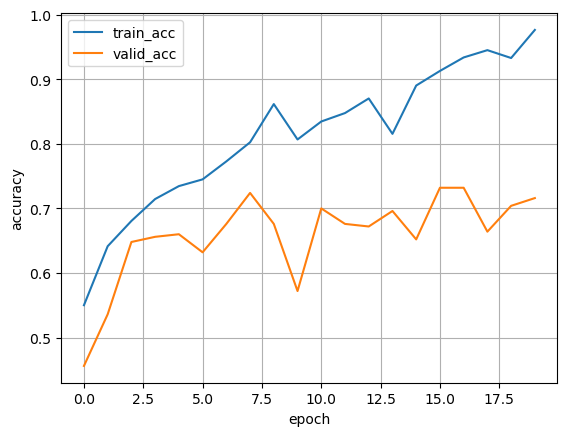

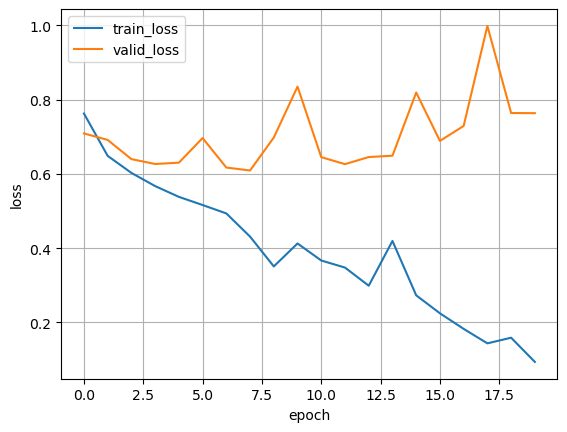

In [45]:
cnn = instantiate_model('cnn')

train_model(
    model=cnn,
    epochs=20,
    optimizer='SGD',
    learning_rate=0.01,
    momentum=0.6
)

  0%|          | 0/20 [00:00<?, ?it/s]

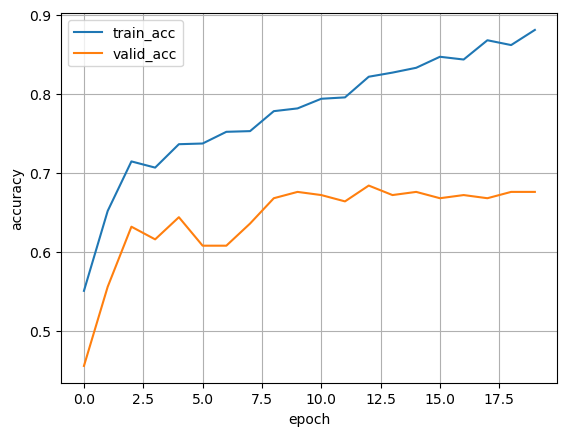

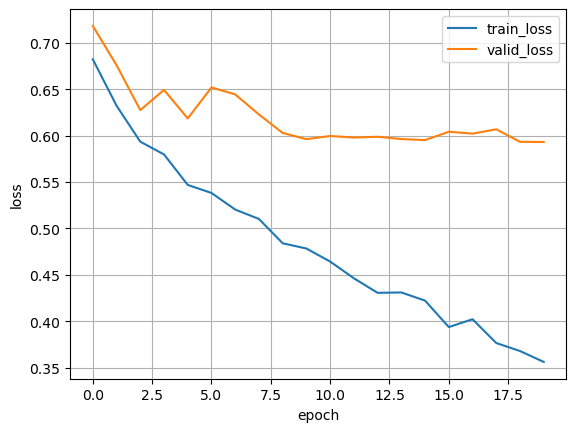

In [54]:
cnn  = instantiate_model('cnn')

train_model(
    model=cnn,
    epochs=20,
    optimizer='SGD',
    learning_rate=0.001,
    momentum=0.5
)

# VGG

  0%|          | 0/20 [00:00<?, ?it/s]

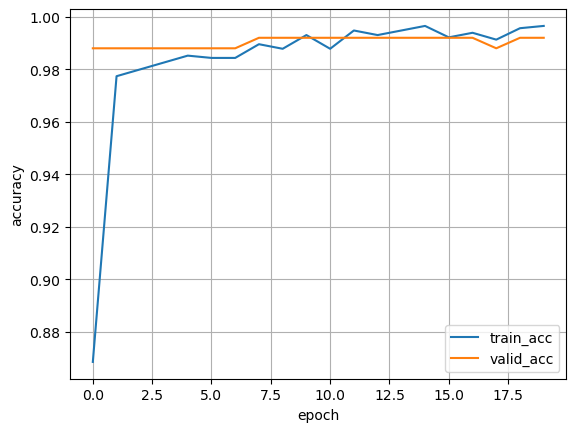

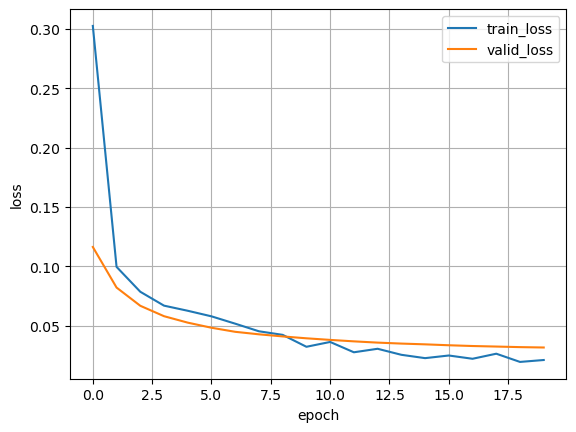

In [55]:
vgg = instantiate_model('vgg')

train_model(
    model=vgg,
    epochs=20,
    optimizer='SGD',
    learning_rate=0.001,
    momentum=0.7
)

  0%|          | 0/20 [00:00<?, ?it/s]

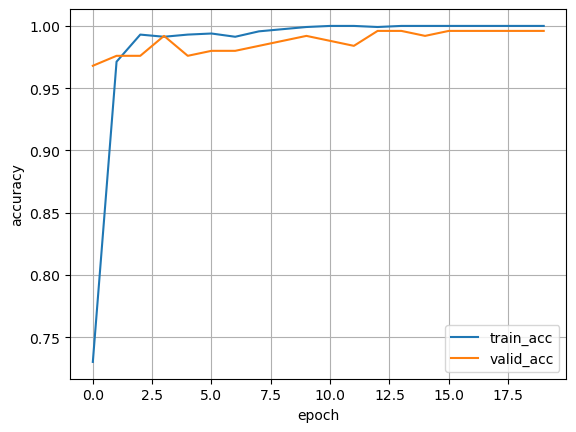

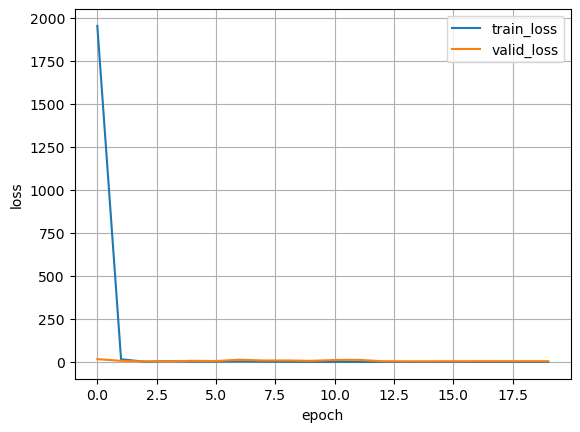

In [48]:
vgg = instantiate_model('vgg')

train_model(
    model=vgg,
    epochs=20,
    optimizer='Adam',
    learning_rate=0.01,
)

# ResNet

  0%|          | 0/20 [00:00<?, ?it/s]

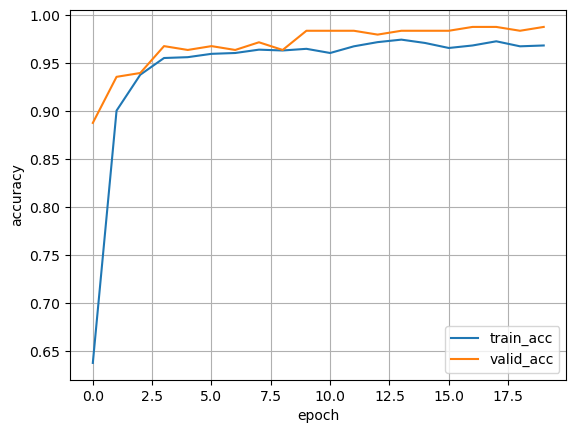

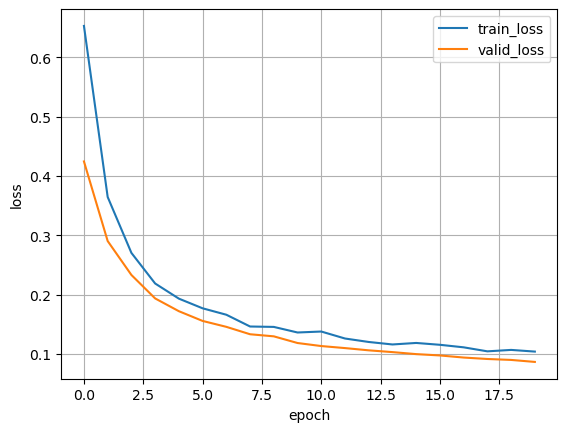

In [49]:
resnet = instantiate_model('resnet')

train_model(
    model=resnet,
    epochs=20,
    optimizer='SGD',
    learning_rate=0.001,
    momentum=0.7
)

  0%|          | 0/20 [00:00<?, ?it/s]

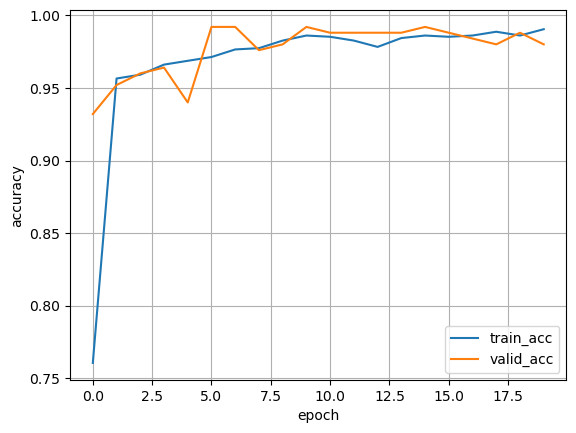

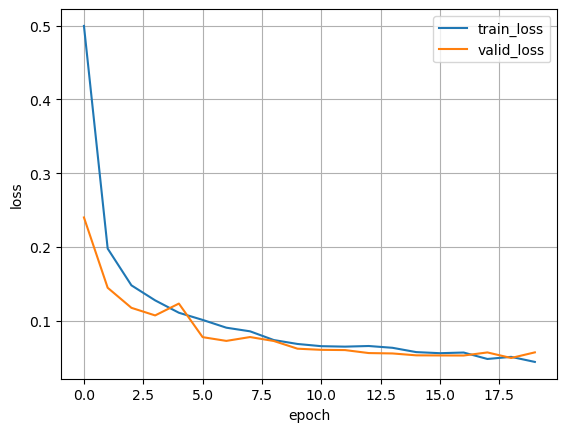

In [50]:
resnet = instantiate_model('resnet')

train_model(
    model=resnet,
    epochs=20,
    optimizer='Adam',
    learning_rate=0.001,
)

# Vision Transformer

  0%|          | 0/20 [00:00<?, ?it/s]

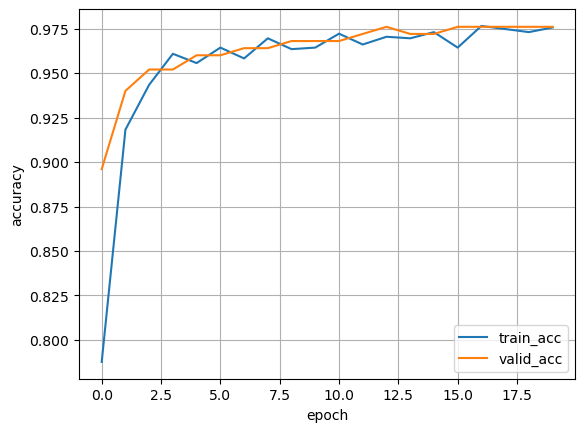

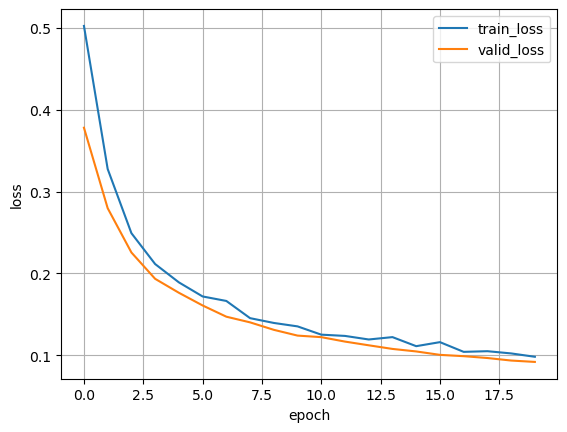

In [51]:
vit = instantiate_model('vit')

train_model(
    model=resnet,
    epochs=20,
    optimizer='SGD',
    learning_rate=0.001,
    momentum=0.7
)

  0%|          | 0/20 [00:00<?, ?it/s]

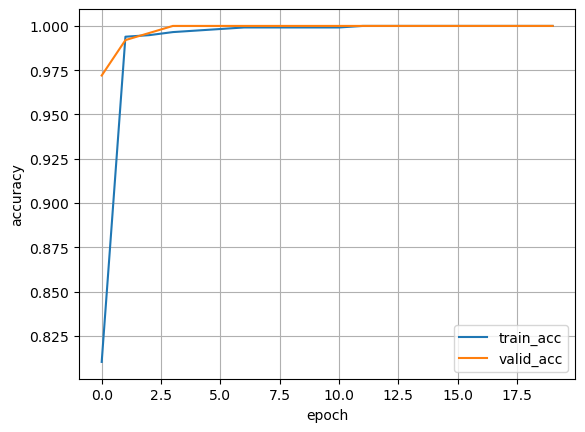

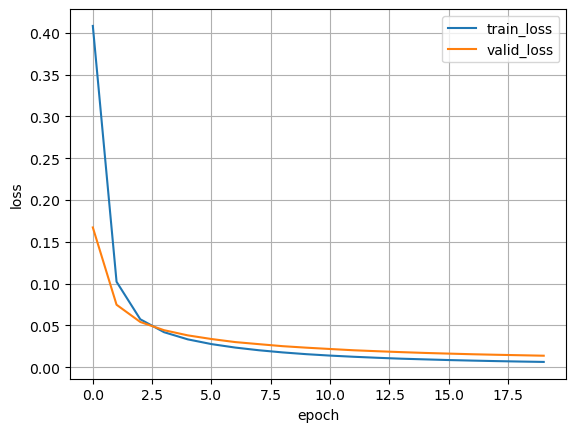

In [52]:
vit = instantiate_model('vit')

train_model(
    model=vit,
    epochs=20,
    optimizer='Adam',
    learning_rate=0.001,
)